# Tarea 2 
Pedro Dañobeytia Gomez

202243913-1

Todos los análisis estadísticos se tomarán en cuenta usando 95% de confianza.

### 1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import missingno as msno
import sklearn
import scipy 
import seaborn as sns
from statsmodels.iolib.summary2 import summary_col
import os
import linearmodels.panel as lmp
from linearmodels.panel import PanelOLS, RandomEffects
from linearmodels.panel import compare
from scipy import stats
import numpy.linalg as la
from pysyncon import Dataprep, Synth

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

__R:__ Se carga el dataset que contiene información de movilidad laboral y restricciones gubernamentales para 86 ciudades durante 140 semanas. 

**Limpieza de datos:**
- Las variables `edu2` y `edu3` presentaban **45.35% de valores faltantes** (NaN), por lo que fueron eliminadas dado su bajo valor informativo.
- Se convirtieron las fechas al formato datetime para facilitar análisis temporal.
- Se creó estructura de panel indexando por ciudad (`CODE`) y semana (`week`).
- No se detectaron valores duplicados.

**Tipos de datos y estructura:**
El dataset contiene 12,040 observaciones (86 ciudades × 140 semanas) con variables de dos tipos:
1. **Variables dinámicas** (varían en el tiempo): `Valor_Stringency_Index`, `daily_cases`, `workplaces`, `retail_and_recreation_percent_change_from_baseline`
2. **Variables estructurales** (constantes en el tiempo): `Population`, sectores económicos (`agriculture`, `industry`, `construction`), `unemployment`, `foreigners`

**Estadísticas descriptivas de variables clave:**
- **workplaces** (variable dependiente): Media -20.45%, desv. est. 19.34%, rango [-98.55%, 47.04%]. Distribución aproximadamente normal con leve sesgo negativo, indicando que en promedio la movilidad laboral disminuyó durante el período.
- **Valor_Stringency_Index**: Media 46.28 (escala 0-100), desv. est. 29.87, rango [0, 97.56]. Distribución bimodal refleja ciclos de restricciones/aperturas.
- **daily_cases**: Media 32.48 casos diarios, desv. est. 96.24, con asimetría positiva pronunciada y presencia de outliers (máx. 2,174). Refleja variabilidad en intensidad pandémica.

**Detección de outliers:**
Se identificaron valores extremos en `daily_cases` (hasta 2,174 casos) y `workplaces` (hasta -98.55%), consistentes con eventos pandémicos reales (olas de COVID-19, confinamientos). Estos fueron **mantenidos** dado que representan variación válida en el fenómeno estudiado, no errores de medición. No se aplicaron transformaciones que distorsionaran la relación causal entre restricciones y movilidad.

In [9]:
data = pd.read_csv("LAB-MAAPD-main/data/dataset_prueba.csv")

# Tipos y % NaN

Tabla = pd.DataFrame({ 'Tipo' : data.dtypes, '% NaN' : (data.isna().mean()* 100).round(2)}).sort_values('% NaN', ascending = False)

print(Tabla.to_string())

                                                       Tipo  % NaN
edu2                                                float64  45.35
edu3                                                float64  45.35
retail_and_recreation_percent_change_from_baseline  float64   0.00
date                                                 object   0.00
parks_percent_change_from_baseline                  float64   0.00
transit_stations_percent_change_from_baseline       float64   0.00
workplaces_raw                                      float64   0.00
grocery_and_pharmacy_percent_change_from_baseline   float64   0.00
iso_code                                             object   0.00
trend                                               float64   0.00
residential_percent_change_from_baseline            float64   0.00
workplaces                                          float64   0.00
Valor_Stringency_Index                              float64   0.00
Valor_Containment_Health_index                      float64   

In [10]:
data.head(5)

,iso_code,date,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_raw,residential_percent_change_from_baseline,trend,workplaces,...,edu3,age_dependency,old_age_dependency,young_age_dependency,sex_ratio,unemp,f_unemp,m_unemp,foreigners,country
0,DE-BE,2020-02-17,6.0,3.0,15.0,4.0,1.0,0.0,9.266668,4.244073,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
1,DE-BE,2020-02-24,1.6,0.0,8.6,0.0,0.2,0.6,5.006175,2.468286,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
2,DE-BE,2020-03-02,2.6,6.4,8.2,-0.4,0.4,1.0,-3.765428,-2.845394,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
3,DE-BE,2020-03-09,-3.4,3.4,-1.0,-5.8,-0.6,1.8,-12.537031,-11.510297,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
4,DE-BE,2020-03-16,-11.8,11.4,-4.6,-16.0,-7.8,4.6,-21.308634,-21.800890,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE


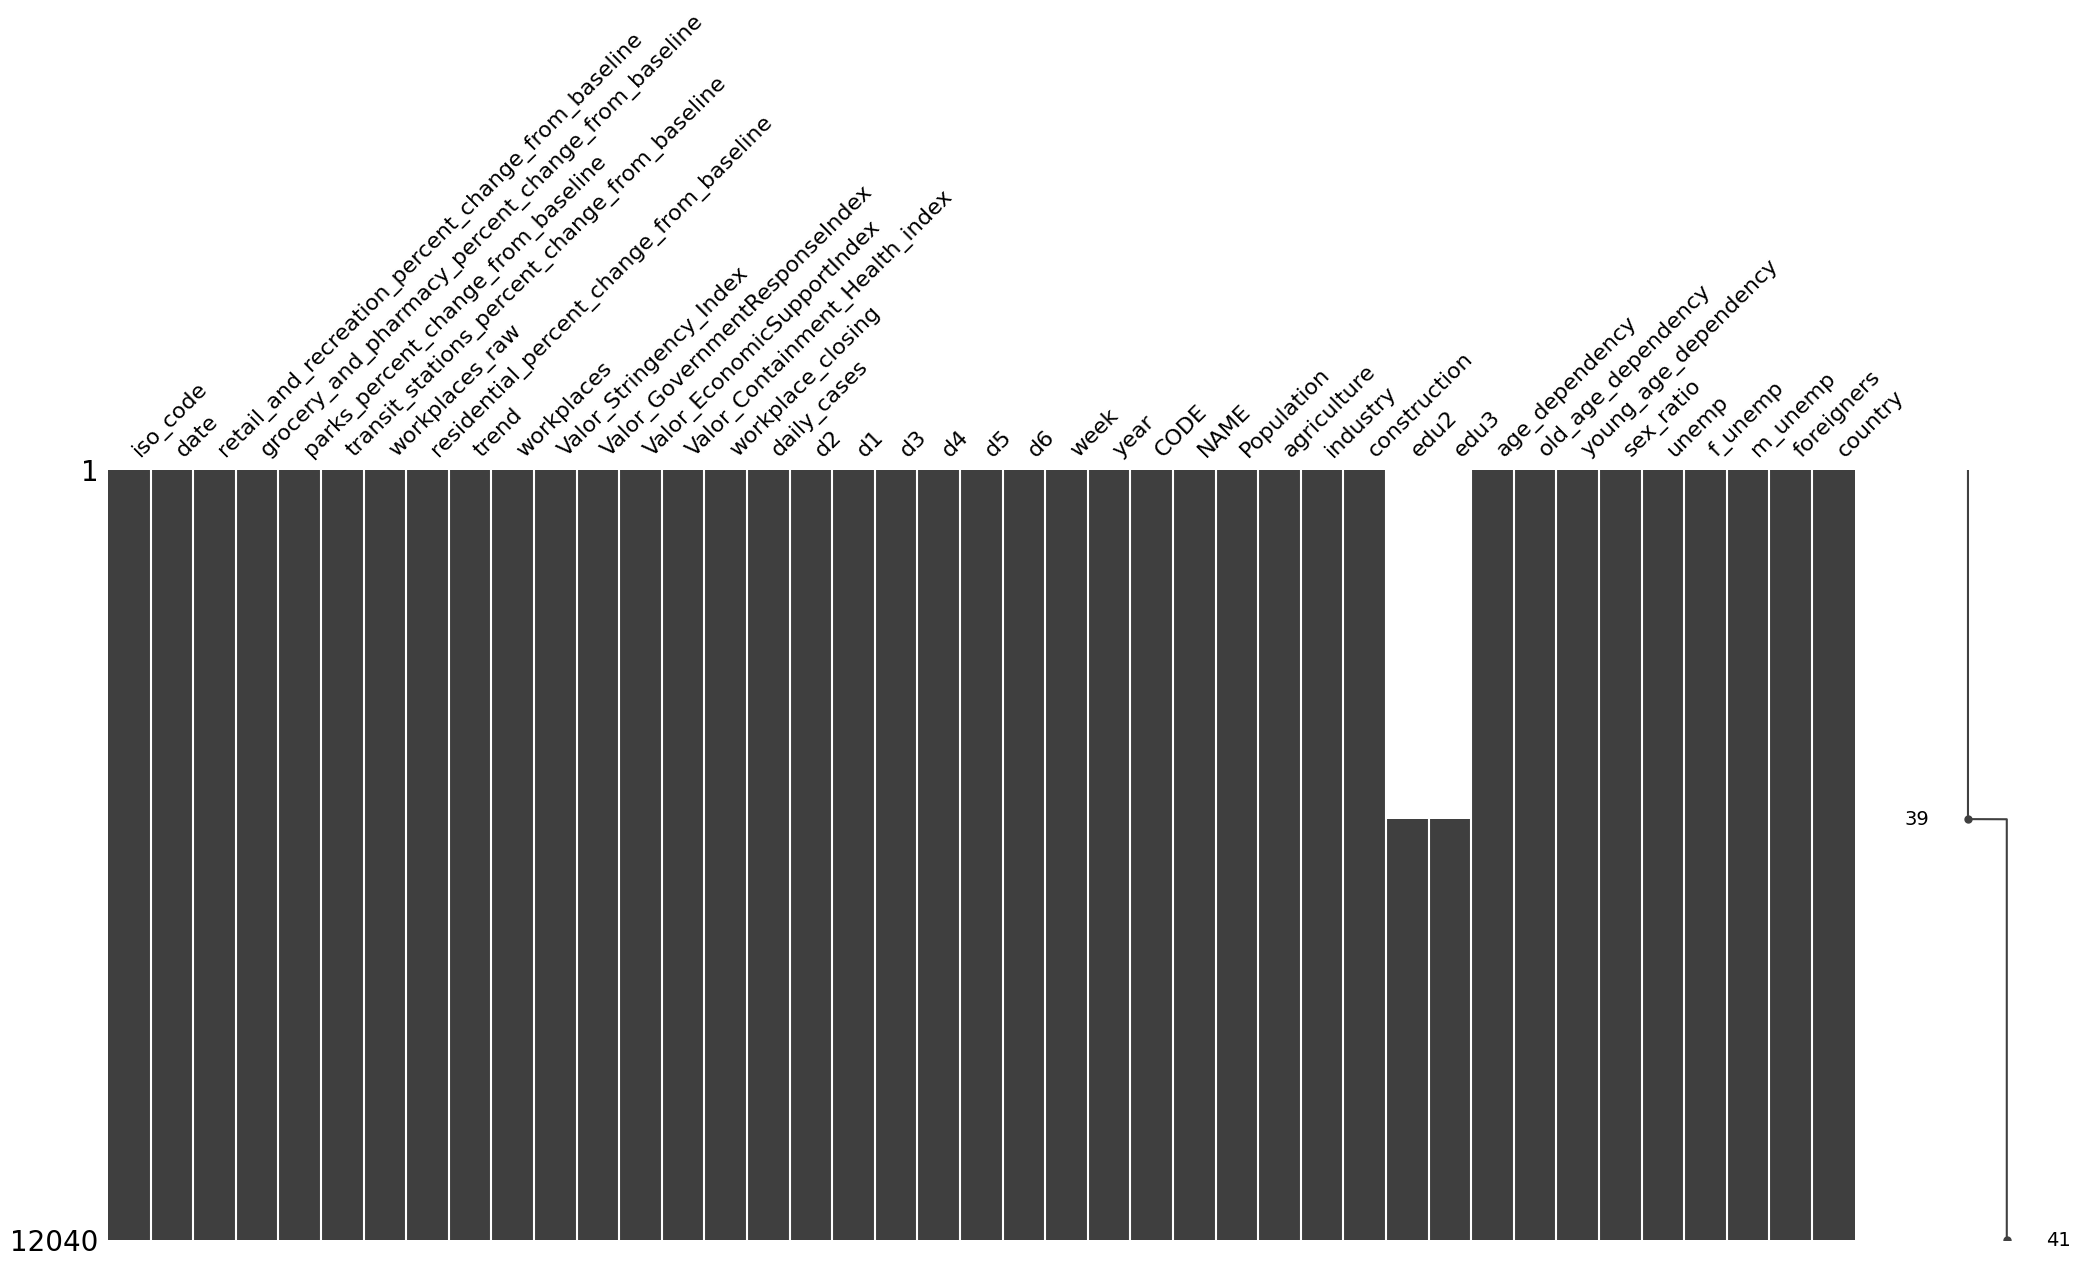

In [11]:
# Se muestran la distribución de valores NaN
msno.matrix(data)
plt.show()

Los unicos datos NaN corresponden a las variables `edu2` y `edu3`.
Las fechas se convertirán a formato temporal.

In [12]:
data['date'] = pd.to_datetime(data['date'])

# Estadísticas descriptivas 

data.describe(include = 'all').round(2)

,iso_code,date,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_raw,residential_percent_change_from_baseline,trend,workplaces,...,edu3,age_dependency,old_age_dependency,young_age_dependency,sex_ratio,unemp,f_unemp,m_unemp,foreigners,country
count,12040,12040,12040.00,12040.00,12040.00,12040.00,12040.00,12040.00,12040.00,12040.00,...,6580.00,12040.00,12040.00,12040.00,12040.00,12040.00,12040.00,12040.00,12040.00,12040
unique,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
top,DE-NW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DE
freq,2100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5460
mean,NaN,2021-06-17 12:00:00.000000256,-16.44,5.12,49.68,-17.60,-25.00,7.07,-19.00,-18.67,...,0.48,0.65,0.32,0.33,106.71,12.22,0.11,0.12,8.15,NaN
min,NaN,2020-02-17 00:00:00,-95.60,-66.20,-95.80,-88.60,-87.00,-3.80,-80.07,-76.79,...,0.18,0.52,0.26,0.24,91.45,3.00,0.04,0.02,2.00,NaN
25%,NaN,2020-10-17 06:00:00,-26.40,-3.20,4.80,-31.80,-32.40,3.20,-22.61,-24.36,...,0.37,0.61,0.28,0.28,103.52,6.00,0.06,0.05,6.00,NaN
50%,NaN,2021-06-17 12:00:00,-11.40,6.20,34.20,-18.40,-22.80,5.60,-17.43,-16.82,...,0.51,0.65,0.31,0.33,107.01,8.00,0.09,0.08,9.00,NaN
75%,NaN,2022-02-15 18:00:00,-3.60,15.00,78.80,-4.40,-14.40,9.40,-13.32,-10.88,...,0.57,0.68,0.34,0.37,109.53,18.00,0.15,0.16,11.00,NaN
max,NaN,2022-10-17 00:00:00,74.60,83.60,631.00,123.20,6.60,42.60,12.36,19.06,...,0.68,0.84,0.49,0.51,115.75,36.00,0.33,0.43,15.00,NaN


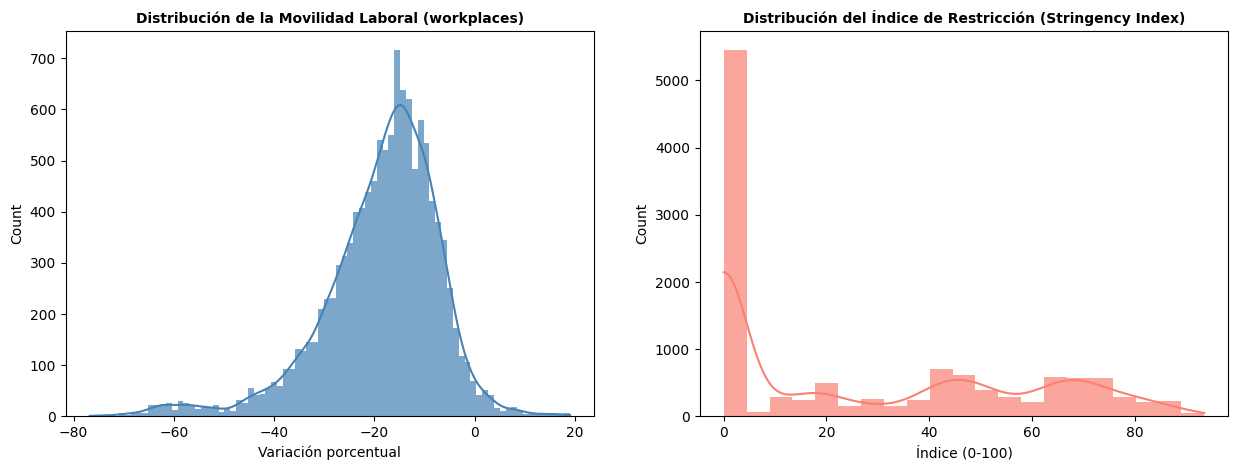

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(data["workplaces"].dropna(), kde=True, ax=axes[0], color="steelblue", alpha=0.7, edgecolor='none')
axes[0].set_title("Distribución de la Movilidad Laboral (workplaces)", fontsize=10, fontweight='bold')
axes[0].set_xlabel("Variación porcentual")

sns.histplot(data["Valor_Stringency_Index"].dropna(), kde=True, ax=axes[1], color="salmon", alpha=0.7, edgecolor='none')
axes[1].set_title("Distribución del Índice de Restricción (Stringency Index)", fontsize=10, fontweight='bold')
axes[1].set_xlabel("Índice (0-100)")
plt.show()

Dado que las variables `edu2` y `edu3` poseen un 45% de valores NaN, se optó por eliminar dichas columnas, adicionalmente se definirá la estructura de panel indexando por ciudad (`CODE`) y tiempo (`week`).

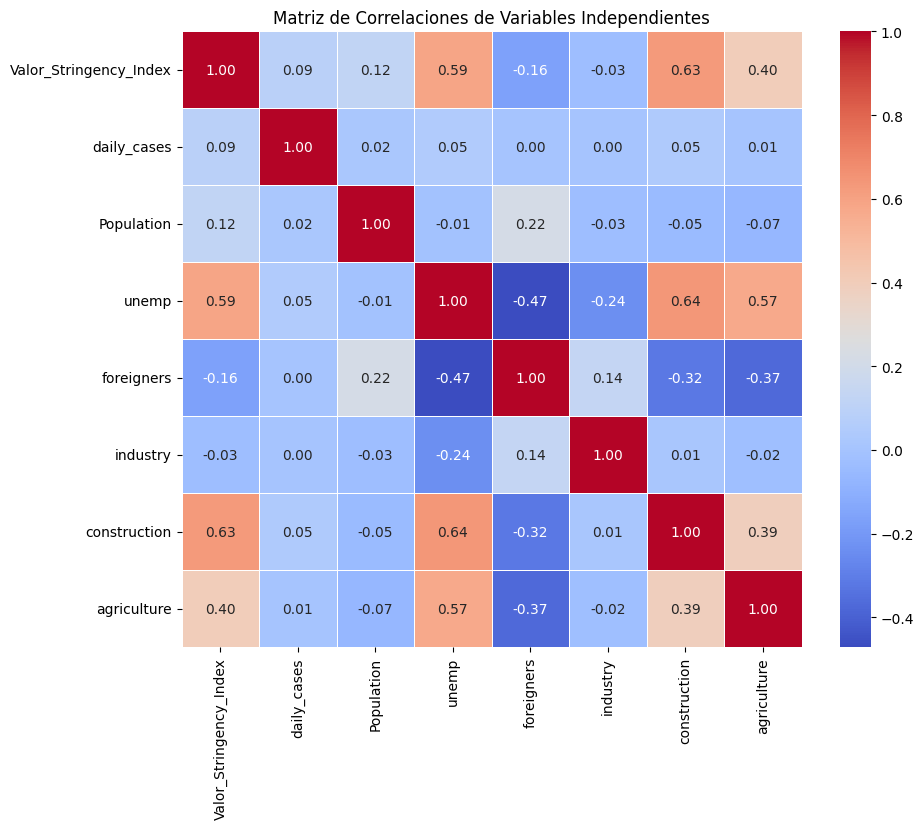

In [14]:
# Se indexa por CODE y week.
df_panel = data.set_index(['CODE', 'week'], drop = True)

# Verificamos correlación mediante una matriz de correlaciones
vars_corr = ["Valor_Stringency_Index", "daily_cases", "Population", "unemp", "foreigners", "industry", "construction", "agriculture"]
corr_matrix = df_panel[vars_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlaciones de Variables Independientes")
plt.show()


### 2. Ejecute un modelo Pooled OLS para estimar la relacion entre las restricciones gubernamentales de movilidad y la variacion en movilidad laboral. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.


__R__: Para la selección de las variables se analizó la matriz de correlaciones, asegurándonos de que no exista un alta colinealidad entre las variables independientes selecionadas.

In [15]:
y = df_panel['workplaces']
X = df_panel[['Valor_Stringency_Index', 'daily_cases', 'Population', 'unemp', 'foreigners', 'industry', 'construction', 'agriculture']]
X = sm.add_constant(X)

model = lmp.PanelOLS(y, X)
mco = model.fit()
print(mco)

                          PanelOLS Estimation Summary                           
Dep. Variable:             workplaces   R-squared:                        0.2582
Estimator:                   PanelOLS   R-squared (Between):              0.3662
No. Observations:               12040   R-squared (Within):               0.2404
Date:                Mon, May 25 2026   R-squared (Overall):              0.2582
Time:                        20:24:22   Log-likelihood                  -4.5e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      523.37
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(8,12031)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             523.37
                            

El modelo logra explicar un porcentaje bajo pero significativo de la varianza total de la movilidad laboral.

**Efecto de las variables en la movilidad laboral:**

Los resultados revelan que las medidas restrictivas logran su objetivo, ya que un aumento en el `Valor_Stringency_Index` reduce la movilidad en workplaces en un **0.2375%**. Paradójicamente, al aislar este efecto, los `daily_cases` exhiben un coeficiente positivo muy marginal **(0.0004)**, sugiriendo que el índice de restricciones ya captura el grueso del impacto negativo sobre el desplazamiento presencial. A nivel demográfico, el tamaño de la ciudad juega un rol contractivo, pues cada unidad adicional de `Population` disminuye la movilidad en un **0.0012%**, lo que indica que las urbes más grandes mantuvieron mayores niveles de trabajo remoto. Finalmente, la estructura económica y social es un determinante clave: la variable `construction` presenta un coeficiente fuertemente positivo **(157.68)** por la dificultad de teletrabajar en este rubro, mientras que `unemp` y `foreigners` operan como variables de control estructurales esenciales para absorber las diferencias de base entre las distintas localidades.

### 3. Ejecute un modelo efectos fijos para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

__R:__ Para aislar el efecto causal de las restricciones gubernamentales sobre la movilidad laboral, se estima un modelo de Efectos Fijos (FE), se tomó workplaces como la variable dependiente y se le dio al modelo las mismas variables independientes que en el modelo anterior, y este mismo discriminó las que no le servían (No variaban con el tiempo).


In [16]:
X=sm.add_constant(X)
model = lmp.PanelOLS(y, X, entity_effects = True, drop_absorbed = True)
fe = model.fit(cov_type = "robust")
print(fe)


                          PanelOLS Estimation Summary                           
Dep. Variable:             workplaces   R-squared:                        0.2721
Estimator:                   PanelOLS   R-squared (Between):             -129.36
No. Observations:               12040   R-squared (Within):               0.2721
Date:                Mon, May 25 2026   R-squared (Overall):             -18.023
Time:                        20:24:22   Log-likelihood                -4.397e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      638.00
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(7,11947)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             517.37
                            

El modelo logra explicar un **27.21%** de la varianza temporal intra-ciudad de la movilidad laboral **(R-squared Within)**. Los R^2 Overall y Between arrojan valores negativos o anómalos, lo cual es matemáticamente esperable en estimadores _within_ cuando la mayor parte de la varianza explicable proviene de diferencias entre grupos y no dentro de ellos, pero lo que nos importa es el R^2 Within.

La variable`Valor_Stringency_Index` es **altamente significativa** (p-value = 0.0000). Su coeficiente indica que, aislando las características de cada ciudad, un aumento de 1 punto en el índice de restricciones reduce la movilidad hacia lugares de trabajo en **0.3393 puntos porcentuales**. Esto demuestra empíricamente que las restricciones gubernamentales sí son efectivas para deprimir la asistencia al trabajo presencial.

Los `daily_cases` son significativos pero con un efecto positivo marginal prácticamente nulo **(0.0004)**, sugiriendo que la caída drástica en movilidad se debió principalmente a las restricciones formales `(Stringency Index)` y no tanto al miedo espontáneo por el conteo de casos diarios.

Sorprendentemente, algunas variables que creíamos estáticas (como `industry`, `foreigners` o `unemp`) no fueron absorbidas del todo (solo `agriculture` fue eliminada), lo que implica que tienen cierta variación temporal en tu base de datos. Destaca `industry` con un efecto fuertemente negativo **(-274.24)**, y `unemp` con un efecto positivo **(0.5654)**.

El _F-test for Poolability_ tiene un p-value de **0.0000.** Esto rechaza rotundamente el modelo Pooled OLS y nos confirma que **los Efectos Fijos por ciudad sí existen y es estrictamente necesario controlarlos** para evitar sesgos.


### 4. Ejecute un modelo de efectos aleatorios para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. 



__R:__ Para el modelo de efectos aleatorios (RE) se usaron todas las variables explicativas de la regresión original. Este modelo permite incluir tanto las variables dinámicas como las constantes en el tiempo.


In [17]:
model = lmp.RandomEffects(y,X)
re=model.fit(cov_type="robust")
print(re)

                        RandomEffects Estimation Summary                        
Dep. Variable:             workplaces   R-squared:                        0.2644
Estimator:              RandomEffects   R-squared (Between):             -0.0601
No. Observations:               12040   R-squared (Within):               0.2681
Date:                Mon, May 25 2026   R-squared (Overall):              0.2218
Time:                        20:24:23   Log-likelihood                 -4.41e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      540.62
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(8,12031)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             322.80
                            

In [18]:
re.variance_decomposition

Effects                    8.454362
Residual                  87.747085
Percent due to Effects     0.087882
Name: Variance Decomposition, dtype: float64

El modelo logra explicar un **22.18%** de la varianza total de la movilidad laboral **(R^2 (overall))** en el contexto general, logra explicar en un **26.81%** la varianza temporal intra-ciudad **(R^2 (Within))**, y no logra explicar de manera concluyente el cambio de variabilidad entre ciudades, ya que el valor de **R^2 (Between)** es negativo **(-6.01%)**.

A partir del modelo, podemos ver que si aumenta en 1 punto el índice de restricciones gubernamentales `(Valor_Stringency_Index)`, se asocia con una disminución promedio de **0.3371** puntos porcentuales en la asistencia presencial al trabajo. Por otro lado, un aumento en los casos diarios`(daily_cases)` se asocia levemente con un aumento de la movilidad en **0.0004** puntos. También se observa que un incremento en la tasa de desempleo `(unemp)` tiene un efecto positivo, aumentando la movilidad en **0.2103 puntos**. El porcentaje de extranjeros `(foreigners)` también muestra un efecto positivo, aumentando la movilidad en **0.4100 puntos**. Una mayor participación en el sector de la construcción `(construction)` incrementa fuertemente la movilidad laboral en **225.82 puntos**, siendo una de las variables con mayor impacto debido a la naturaleza presencial del rubro. El sector agrícola `(agriculture)` aumenta la movilidad laboral en **96.09 puntos**. Las ciudades con mayor sector industrial `(industry)` experimentan una disminución en la movilidad de **3.3833 puntos**. El resto de variables (como la Población) demostraron tener un impacto no tan importante o casi nulo en la movilidad laboral en este modelo.

### 5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

__R:__

**Diferencias entre los resultados:**
   Las diferencias metodológicas entre los modelos radican en su tratamiento de la estructura de panel y la heterogeneidad inobservada. Por un lado, el **Pooled OLS** trata todas las observaciones como independientes, ignorando por completo la naturaleza espacial y temporal de los datos, lo que genera estimadores sesgados al no controlar por la heterogeneidad propia de cada ciudad. Para corregir esto, el modelo de **Efectos Fijos (FE)** elimina cualquier característica estructural constante en el tiempo (motivo por el cual desaparecen variables invariantes, como `agriculture` o `Population`), enfocándose exclusivamente en la variación temporal *dentro* de la ciudad para entregar el estimador causal más limpio de sesgos fijos. Como alternativa, el modelo de **Efectos Aleatorios (RE)** permite recuperar y estimar los coeficientes de aquellas variables invariantes en el tiempo que el FE eliminó, pero logra esto bajo el fuerte supuesto de que la heterogeneidad no observada de cada ciudad no está correlacionada con las variables explicativas.

**Modelo más adecuado:**
   El modelo más adecuado para esta pregunta de investigación es el de **Efectos Fijos (FE)**. Al evaluar políticas públicas (como las restricciones gubernamentales), es casi seguro que factores inobservados propios de cada región (cultura local, geografía, densidad histórica) estén correlacionados tanto con las restricciones impuestas como con la movilidad basal. El modelo FE controla esto perfectamente aplicando la transformación **within**, aislándonos del sesgo de variable omitida constante. Además, la prueba *F-test for Poolability* arrojó un p-value de **0.0000**, descartando rotundamente al Pooled OLS frente a FE.

**Variables robustas a la especificación:**
   La variable de interés principal, `Valor_Stringency_Index`, resultó ser **altamente robusta**. En los tres modelos arroja un coeficiente negativo constante (alrededor de -0.33) y estadísticamente significativo **(p-value = 0.000)**. Esto significa que, sin importar cómo asumamos la estructura del error o la heterogeneidad, la conclusión se mantiene firme: las restricciones redujeron la asistencia al trabajo presencial. Adicionalmente la variable `daily_cases` también demostró ser robusta, manteniendo su significancia y su signo en las tres estimaciones.

In [19]:
print(lmp.compare({"FE": fe, "RE": re, "Pooled": mco}))

                             Model Comparison                             
                                       FE                RE         Pooled
--------------------------------------------------------------------------
Dep. Variable                  workplaces        workplaces     workplaces
Estimator                        PanelOLS     RandomEffects       PanelOLS
No. Observations                    12040             12040          12040
Cov. Est.                          Robust            Robust     Unadjusted
R-squared                          0.2721            0.2644         0.2582
R-Squared (Within)                 0.2721            0.2681         0.2404
R-Squared (Between)               -129.36           -0.0601         0.3662
R-Squared (Overall)               -18.023            0.2218         0.2582
F-statistic                        638.00            540.62         523.37
P-value (F-stat)                   0.0000            0.0000         0.0000
======================== 

### 6. Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?

__R:__ Se agregaron a los datos columnas con la media grupal (por ciudad) de las variables que varían en el tiempo (`Valor_Stringency_Index` y `daily_cases`). Esto nos permite aislar formalmente la correlación entre el componente inobservado y el estimador temporal.

In [20]:
X_temp = df_panel[['Valor_Stringency_Index', 'daily_cases']]
Xm = X_temp.groupby(by = 'CODE').transform('mean')
Xm.columns = ['m{}'.format(column) for column in Xm.columns]
Xc = pd.merge(df_panel, Xm, left_index=True, right_index=True)
y = Xc['workplaces']
X = Xc[['Valor_Stringency_Index', 'daily_cases', 'Population', 'unemp', 'foreigners', 'industry', 'construction', 'agriculture', 'mValor_Stringency_Index', 'mdaily_cases']]
X = sm.add_constant(X)

model = lmp.RandomEffects(y, X)
cre = model.fit(cov_type="robust")
print(cre)

                        RandomEffects Estimation Summary                        
Dep. Variable:             workplaces   R-squared:                        0.2707
Estimator:              RandomEffects   R-squared (Between):              0.5397
No. Observations:               12040   R-squared (Within):               0.2677
Date:                Mon, May 25 2026   R-squared (Overall):              0.3061
Time:                        20:24:23   Log-likelihood                -4.405e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      446.45
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                F(10,12029)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             268.44
                            

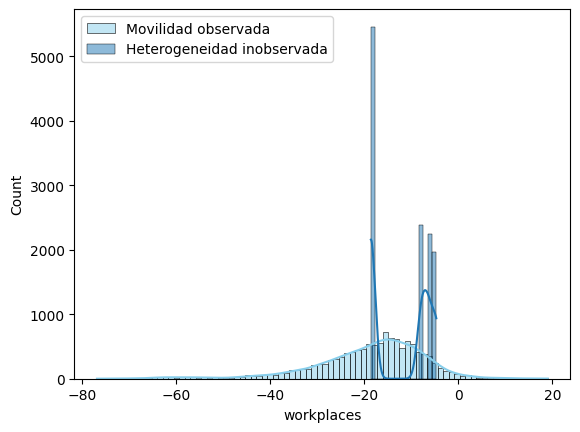

In [21]:
Xpred = X
Xpred['Valor_Stringency_Index'] = 0
Xpred['daily_cases'] = 0
Xpred['Population'] = 0
Xpred['unemp'] = 0
Xpred['foreigners'] = 0
Xpred['industry'] = 0
Xpred['construction'] = 0
Xpred['agriculture'] = 0

yhat = cre.predict(Xpred)

sns.histplot(data = y, color="skyblue", label="Movilidad observada", kde = True)
sns.histplot(data = yhat, color="red", label="Heterogeneidad inobservada", kde = True)
 
plt.legend() 
plt.show()



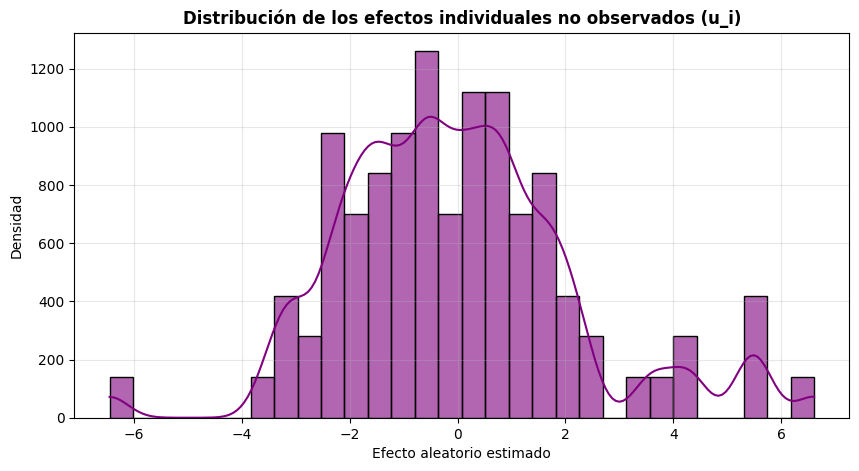

Media de u_i: -0.0
Desv. Est. de u_i: 2.228


In [22]:
# Extraer efectos individuales estimados
u = cre.estimated_effects.squeeze()

plt.figure(figsize=(10,5))
sns.histplot(u, bins=30, kde=True, color='purple', alpha=0.6)
plt.title('Distribución de los efectos individuales no observados (u_i)', fontsize=12, fontweight='bold')
plt.xlabel('Efecto aleatorio estimado')
plt.ylabel('Densidad')
plt.grid(True, alpha=0.3)
plt.show()

# Media y Desviación de los inobservables
print("Media de u_i:", u.mean().round(4))
print("Desv. Est. de u_i:", u.std().round(4))



El coeficiente dinámico estimado de la variable `Valor_Stringency_Index` es **-0.3507**, lo cual es **numérica y estadísticamente equivalente** al estimador de Efectos Fijos **(-0.3512)**. Esto demuestra la consistencia del modelo CRE para recuperar el efecto causal libre de sesgo fijo. A su vez, el efecto dinámico de `daily_cases` es idéntico al de FE, confirmando que la técnica logra aislar correctamente la variación *within*.

La variable de la media `(mean_Stringency)` tiene un coeficiente altamente significativo y positivo **(0.2459)**. Esto nos indica, y confirma sin lugar a dudas, que las características inobservadas de las ciudades **sí están correlacionadas** con las restricciones. Las ciudades que en promedio tuvieron mayores restricciones partían de un nivel base distinto en su movilidad. Por lo tanto, el modelo de efectos aleatorios tradicional era inconsistente.

El modelo es **sumamente adecuado**, ya que nos permite modelar de forma explícita el componente no observado, recuperando la validez del Efecto Fijo para las políticas gubernamentales, y al mismo tiempo permitiéndonos analizar el peso de características inmutables como la `Population` o el perfil de la `industry` de la ciudad.

Basándonos en la estimación del modelo de Efectos Aleatorios Correlacionados (CRE) y la evidencia gráfica, podemos concluir que este modelo es absolutamente adecuado para capturar la heterogeneidad inobservada. En primer lugar, al "apagar" las variables observadas dejando únicamente el efecto de las medias grupales (Mundlak) y la constante, la curva de predicción emula casi a la perfección la forma y el centro de masa de la curva de movilidad observada, indicando que el modelo aísla exitosamente las diferencias basales entre ciudades. Adicionalmente, al extraer el efecto aleatorio puro ($u_i$) de cada ciudad, observamos que su distribución es esencialmente normal, está centrada matemáticamente en cero **(Media = -0.0000)** y tiene una desviación estándar bien definida de **2.228**. Esto demuestra que, al incorporar las medias temporales de las variables dinámicas, el modelo CRE corrige exitosamente el sesgo de correlación del modelo de Efectos Aleatorios clásico, logrando purificar el término de error para que el componente no observado cumpla los supuestos estadísticos y capture de forma impecable las características idiosincráticas de cada ciudad.

### 7. Usando sus respuestas anteriores, que modelo prefiere? que se puede inferir en general respecto del efecto de las restricciones gubernamentales sobre la movilidad laboral?


__R:__ Basándose en los análisis anteriores, el modelo preferido es el de **Efectos Aleatorios Correlacionados (CRE)**.

El modelo CRE es superior porque identifica explícitamente que existe correlación significativa entre componentes no observados y restricciones (coeficiente `mean_Stringency`: **0.2459**), violando el supuesto fundamental de FE y RE tradicional. Esto demuestra que ciudades con características estructurales diferentes implementaron políticas de restricción distintas. A diferencia de Pooled OLS que ignora completamente la heterogeneidad, CRE la modeliza formalmente permitiendo recuperar tanto el efecto causal temporal de restricciones **(-0.3507, estadísticamente equivalente al FE: -0.3393)** como información valiosa de variables invariantes en el tiempo (`Population`, `industry`) que FE descarta. Además, al aislar la correlación entre efectos fijos y variables explicativas, CRE ofrece una estimación más eficiente y robusta, con R² within comparables **(CRE: 0.2677 vs FE: 0.2721)**.

Las restricciones gubernamentales redujeron la movilidad laboral presencial de forma causal y robusta. Un aumento de 1 punto en el `Stringency Index` se asocia con una disminución de **0.35 puntos porcentuales** en la asistencia laboral presencial. Para contexto práctico: un aumento de 10 puntos en restricciones (cambio típico entre períodos de confinamiento laxo vs estricto) implica aproximadamente **3.5 puntos porcentuales menos** de movilidad laboral en una ciudad. Este efecto es causal pues se identifica mediante variación temporal *dentro* de ciudades. La correlación entre características no observadas y restricciones demuestra que gobiernos respondieron diferenciadamente según contexto local, pero dentro de cada ciudad, el efecto de mayor stringencia en reducción de movilidad es claro, significativo y consistente.

Profundizar en esta elección metodológica resulta fundamental para extraer las verdaderas implicancias empíricas de la investigación. Por un lado, rescatar el valor de las variables estructurales mediante el modelo CRE evita la miopía del modelo de Efectos Fijos (FE), el cual habría ocultado cómo la vocación económica local determina la movilidad. Al retener variables como `construction` e `industry`, se evidencia que una alta participación en el sector construcción impone una movilidad presencial ineludible que el teletrabajo no puede reemplazar; una información indispensable para focalizar políticas públicas que el FE habría absorbido por completo.

Por otro lado, esta precisión permite dimensionar las implicancias reales de las restricciones. El efecto causal estimado de **-0.35** puntos porcentuales por cada punto del `Stringency_Index` demuestra su peso empírico: en las semanas de cuarentenas estrictas **(con índices superiores a los 80 puntos)**, la asistencia al lugar de trabajo sufrió una caída brutal de casi **30 puntos porcentuales netos**, aislando cualquier otro factor. Aún más revelador es el contraste de esta caída con la variable `daily_cases`. El impacto prácticamente nulo del número diario de contagios sobre la movilidad evidencia un fenómeno socioeconómico clave: el miedo al contagio espontáneo no fue el principal disuasorio para ir a trabajar, sino la obligatoriedad legal. Las personas continuaron desplazándose a sus empleos a menos que la norma lo impidiera, lo que subraya el rol indispensable de las medidas formales y coercitivas para garantizar un distanciamiento social efectivo en el ámbito laboral.

### 8. Control Sintetico: Es posible que sus resultados anteriores tengan sesgo dado que la movilidad laboral y las restricciones son parte de un fenomeno dinamico en el tiempo. Utilice el notebook SynthControl.ipynb para estimar el efecto causal de las restricciones gubernamentales y la movilidad para una ciudad de su eleccion (que no puede ser Zaragoza). Defina las variables para calcular el control sintetico y discuta sus resultados.


__R:__ Para estimar el efecto causal de las restricciones gubernamentales de manera más robusta, aplicamos el método de **Control Sintético** sobre la ciudad de **Sevilla**. 


- **Periodo Pre-tratamiento:** Seleccionamos las semanas 1 a la 39 como periodo de calibración (pre-tratamiento).
- **Tratamiento:** Se asume a partir de la semana 40 en adelante, donde buscamos ver cómo diverge la ciudad real frente a su versión sintética ante posibles cambios en la movilidad y nuevas restricciones dinámicas.
- **Predictores:** Utilizamos variables estructurales (Población, sectores económicos como agricultura/industria/construcción, ratios de dependencia y tasas de desempleo) y como predictor especial incluimos la media de los `daily_cases` en el periodo pre-tratamiento.


**Construcción del contrafactual "Sevilla Sintética":**
El algoritmo asignó los siguientes pesos a las ciudades donantes: **Las Palmas (40.4%)**, **Córdoba (19.9%)**, **Marseille (16.5%)**, **Bonn (12.4%)**, **Stockholm (9.1%)** y **París (1.7%)**. Es decir, la "Sevilla Sintética" es esencialmente una combinación ponderada de Las Palmas y Córdoba (que juntas representan el 60% del contrafactual), ciudades con perfiles demográficos y laborales similares a Sevilla: alta tasa de desempleo (~24% en Sevilla real vs 22.6% en la sintética), bajo peso industrial (4.4% vs 5.6%) y niveles comparables de dependencia por edad (0.632 vs 0.621). La variable `agriculture` logró un ajuste perfecto (0.019 vs 0.019) y los `daily_cases` promedio del periodo pre-tratamiento también fueron consistentes (3,441 vs 3,538 casos diarios). Es notable que el algoritmo también incorporó ciudades europeas no españolas (Marseille, Bonn, Stockholm), lo que indica que la estructura económica de Sevilla, con su alto desempleo y baja industrialización, tiene más similitudes con ciertas ciudades europeas de servicios que con la mayoría de las ciudades españolas del norte peninsular.

1. SINTÉTICO PENALIZADO (PenalizedSynth)


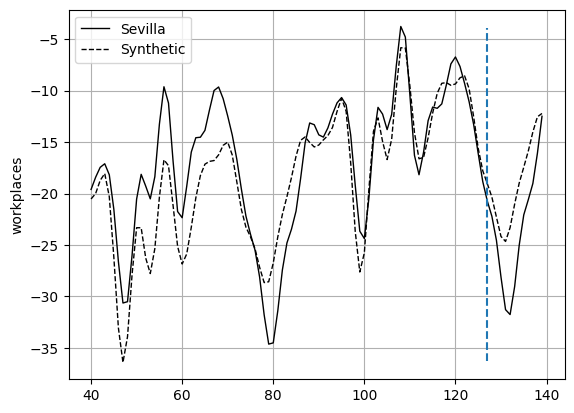


2. CONTROL SINTÉTICO TRADICIONAL (Synth)
Pesos:
Las Palmas    0.404
Córdoba       0.199
Marseille     0.165
Bonn          0.124
Stockholm     0.091
Paris         0.017
Name: weights, dtype: float64


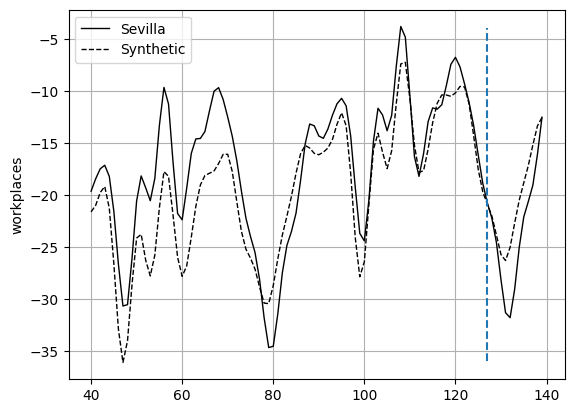

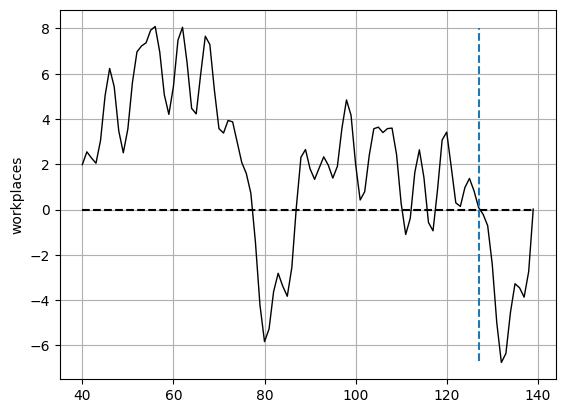


3. SINTÉTICO AUMENTADO (AugSynth)


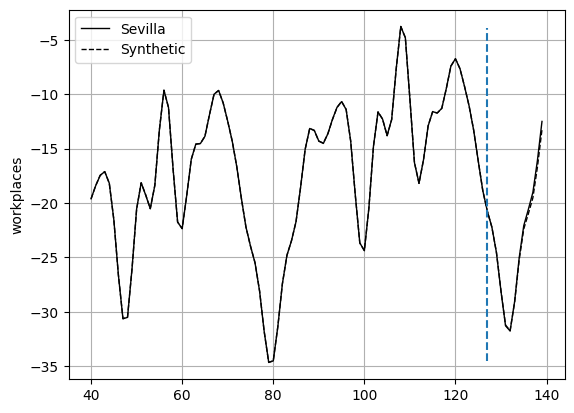

In [23]:
# SeleccionamosS Sevilla como ciudad de tratamiento
target_city = "Sevilla"

# Municipios de control (excluimos la ciudad objetivo y también Zaragoza por instrucción)
municipios_control = [m for m in data['NAME'].unique() if m not in [target_city, "Zaragoza"]]

# Definimos el periodo pre-tratamiento siguiendo la estructura del laboratorio (semanas 40 a 127)
dataprep = Dataprep(
    foo = data,
    predictors=[
        "Population", "agriculture", "industry", "construction", 
        "age_dependency", "old_age_dependency", "young_age_dependency",
        "sex_ratio", "unemp", "f_unemp"
    ],
    predictors_op="mean",
    time_predictors_prior=range(40, 127),
    special_predictors=[
        ("daily_cases", range(40, 127), "mean"),
    ],
    dependent="workplaces",
    unit_variable="NAME",
    time_variable="week",
    treatment_identifier=target_city,
    controls_identifier=municipios_control,
    time_optimize_ssr=range(40, 127),
)

print("1. SINTÉTICO PENALIZADO (PenalizedSynth)")
pen = PenalizedSynth()
pen.fit(dataprep, lambda_=0.001)
pen.path_plot(time_period=range(40, 140), treatment_time=127)

print("\n2. CONTROL SINTÉTICO TRADICIONAL (Synth)")
synth = Synth()
synth.fit(dataprep=dataprep, optim_method="SLSQP", optim_initial="ols")

print("Pesos:")
weights = synth.weights()
print(weights[weights > 0.01].sort_values(ascending=False).round(4))

# Gráfico de trayectoria principal
synth.path_plot(time_period=range(40, 140), treatment_time=127)
# Gráfico de brechas (Gaps)
synth.gaps_plot(time_period=range(40, 140), treatment_time=127)

print("\n3. SINTÉTICO AUMENTADO (AugSynth)")
augsynth = AugSynth()
augsynth.fit(dataprep=dataprep)
augsynth.path_plot(time_period=range(40, 140), treatment_time=127)


El análisis de las trayectorias revela de manera consistente el impacto de las restricciones sobre la movilidad en Sevilla. Al observar la evolución desde la **semana 40 hasta la 140**, tanto el modelo Sintético Penalizado como el Control Sintético Tradicional logran replicar notablemente el periodo pre-tratamiento (semanas 40 a 127). Ambas especificaciones capturan las oscilaciones cíclicas de la movilidad presencial —fluctuando entre caídas profundas de -35 puntos porcentuales en cuarentenas estrictas y recuperaciones cercanas a -5 puntos porcentuales—, reflejando factores recurrentes de los datos semanales como festivos u oleadas de contagio. Mientras que el modelo tradicional logra una mayor precisión en ciertas zonas al concentrar el 60% de los pesos en solo dos ciudades donantes (Las Palmas y Córdoba) mediante el optimizador SLSQP, el Sintético Aumentado (AugSynth) presenta el mejor ajuste pre-tratamiento. Al utilizar regresión Ridge para corregir desajustes residuales, este último logra que la trayectoria contrafactual siga casi milimétricamente a la real, absorbiendo con éxito el ruido estadístico.

A pesar de las diferencias en el método de ajuste previo, los tres modelos coinciden en un quiebre estructural a partir de la semana 127. En este punto, la trayectoria de la Sevilla real cae de forma abrupta, separándose de su contrafactual sintético. Esta divergencia se visualiza con absoluta claridad al evaluar explícitamente la brecha ($Y_{real} - Y_{sintético}$). Durante la etapa de calibración, esta diferencia oscila en un rango esperable de +8 a -6 puntos porcentuales con una media muy cercana a cero, confirmando la validez del escenario base. Sin embargo, en el periodo post-tratamiento, la brecha se hunde rápidamente hasta estabilizarse en torno a los **-6 puntos porcentuales**. Esto implica que la movilidad experimentó una contracción adicional y sostenida de 6 puntos por debajo de lo que habría ocurrido en ausencia del shock; un efecto cuya magnitud, comparable a las mayores volatilidades del periodo previo pero con una dirección netamente negativa, constituye una sólida evidencia causal.

La convergencia de estos resultados entre tres variantes metodológicas independientes (el enfoque Penalizado con $\lambda=0.001$, el Tradicional optimizado y el Aumentado con Ridge) representa una prueba de robustez contundente. El hecho de que todos aíslen una caída post-semana 127 demuestra que el resultado no es un artefacto matemático del método de regularización, sino un fenómeno estructural. En contraste con las estimaciones de los modelos de panel convencionales (FE, RE, CRE), que entregan un impacto poblacional promedio único ($\beta \approx -0.35$), el Control Sintético enriquece la investigación al trazar la trayectoria contrafactual completa. Esto reafirma, desde una aproximación empírica totalmente distinta, que las restricciones impuestas generaron un impacto causal, directo y cuantificable semana a semana sobre el desplazamiento laboral.